In [1]:
%cd "/nas/longleaf/home/amele/Bios 740/Final project"


/nas/longleaf/home/amele/Bios 740/Final project


/nas/longleaf/home/amele/.conda/envs/spert_env/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
!cp ADKG.json spert/ADKG.json
!cp MDKG.json spert/MDKG.json
%cd "/nas/longleaf/home/amele/Bios 740/Final project/spert"
!ls

/nas/longleaf/home/amele/Bios 740/Final project/spert
ADKG.json	  configs      LICENSE	  __pycache__	    scripts
args.py		  data	       MDKG.json  README.md	    spert
config_reader.py  __init__.py  outputs	  requirements.txt  spert.py


In [3]:
%cd "/nas/longleaf/home/amele/Bios 740/Final project/spert"

/nas/longleaf/home/amele/Bios 740/Final project/spert


In [4]:
import json
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

with open("ADKG.json", "r") as f:
    adkg = json.load(f)

with open("MDKG.json", "r") as f:
    mdkg = json.load(f)

In [5]:
import os

folders = [
    "data/datasets/adkg",
    "data/datasets/mdkg",
    "data/types",
    "configs",
    "outputs/adkg",
    "outputs/mdkg",
    "scripts"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("SpERT folders created.")

SpERT folders created.


In [6]:
%%writefile scripts/convert_to_spert.py

import json
import re
import os
from collections import Counter


def simple_tokenize_with_offsets(text):
    tokens = []
    offsets = []

    for match in re.finditer(r"\w+|[^\w\s]", text):
        tokens.append(match.group())
        offsets.append((match.start(), match.end()))

    return tokens, offsets


def char_span_to_token_span(start, end, offsets):
    token_indices = []

    for i, (tok_start, tok_end) in enumerate(offsets):
        if tok_start < end and tok_end > start:
            token_indices.append(i)

    if len(token_indices) == 0:
        return None

    # SpERT usually uses exclusive end index
    return token_indices[0], token_indices[-1] + 1


def convert_split(examples):
    docs = []
    skipped_entities = 0
    skipped_relations = 0

    for ex in examples:
        text = ex["text"]
        tokens, offsets = simple_tokenize_with_offsets(text)

        entities = []
        ent_id_to_index = {}

        for ent in ex["entities"]:
            span = char_span_to_token_span(ent["start"], ent["end"], offsets)

            if span is None:
                skipped_entities += 1
                continue

            start_tok, end_tok = span

            ent_index = len(entities)
            entities.append({
                "type": ent["type"],
                "start": start_tok,
                "end": end_tok
            })

            ent_id_to_index[ent["id"]] = ent_index

        relations = []

        for rel in ex["relations"]:
            head_id = rel["head"]["id"]
            tail_id = rel["tail"]["id"]

            if head_id not in ent_id_to_index or tail_id not in ent_id_to_index:
                skipped_relations += 1
                continue

            relations.append({
                "type": rel["type"],
                "head": ent_id_to_index[head_id],
                "tail": ent_id_to_index[tail_id]
            })

        docs.append({
            "tokens": tokens,
            "entities": entities,
            "relations": relations,
            "orig_id": ex.get("sent_id", "")
        })

    return docs, skipped_entities, skipped_relations


def write_json(docs, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(docs, f, indent=2)


def collect_types(data):
    entity_counts = Counter()
    relation_counts = Counter()

    for split in ["train", "dev", "test"]:
        for ex in data[split]:
            for ent in ex["entities"]:
                entity_counts[ent["type"]] += 1

            for rel in ex["relations"]:
                relation_counts[rel["type"]] += 1

    return entity_counts, relation_counts


def convert_dataset(input_file, output_dir, dataset_name):
    with open(input_file, "r", encoding="utf-8") as f:
        data = json.load(f)

    os.makedirs(output_dir, exist_ok=True)

    for split in ["train", "dev", "test"]:
        docs, skipped_entities, skipped_relations = convert_split(data[split])
        out_path = os.path.join(output_dir, f"{split}.json")
        write_json(docs, out_path)

        print(f"{dataset_name} {split}: wrote {len(docs)} examples")
        print(f"  skipped_entities={skipped_entities}")
        print(f"  skipped_relations={skipped_relations}")

    entity_counts, relation_counts = collect_types(data)

    labels = {
        "entity_labels": list(entity_counts.keys()),
        "relation_labels": list(relation_counts.keys())
    }

    with open(os.path.join(output_dir, "labels.json"), "w", encoding="utf-8") as f:
        json.dump(labels, f, indent=2)

    print()
    print(dataset_name, "entity labels:")
    print(entity_counts)

    print()
    print(dataset_name, "relation labels:")
    print(relation_counts)


if __name__ == "__main__":
    convert_dataset("ADKG.json", "data/datasets/adkg", "adkg")
    convert_dataset("MDKG.json", "data/datasets/mdkg", "mdkg")

Overwriting scripts/convert_to_spert.py


In [7]:
!python scripts/convert_to_spert.py

adkg train: wrote 5605 examples
  skipped_entities=0
  skipped_relations=0
adkg dev: wrote 1206 examples
  skipped_entities=0
  skipped_relations=0
adkg test: wrote 1220 examples
  skipped_entities=0
  skipped_relations=0

adkg entity labels:
Counter({'disease': 8579, 'gene': 4920, 'drug': 2857, 'method': 2736, 'other': 1540, 'mutation': 227})

adkg relation labels:
Counter({'abbreviation_for': 1870, 'associated_with': 1177, 'hyponym_of': 649, 'treatment_for': 592, 'risk_factor_of': 458, 'help_diagnose': 355, 'characteristic_of': 346, 'treatment_target_for': 49})
mdkg train: wrote 4825 examples
  skipped_entities=0
  skipped_relations=0
mdkg dev: wrote 941 examples
  skipped_entities=0
  skipped_relations=0
mdkg test: wrote 912 examples
  skipped_entities=0
  skipped_relations=0

mdkg entity labels:
Counter({'disease': 8951, 'method': 7972, 'Health_factors': 4498, 'drug': 2145, 'physiology': 1615, 'gene': 1298, 'region': 1161, 'signs': 557, 'symptom': 463})

mdkg relation labels:
Count

In [8]:
def summarize_dataset(data, name):
    rows = []

    for split in ["train", "dev", "test"]:
        examples = data[split]

        num_sentences = len(examples)
        num_entities = sum(len(x["entities"]) for x in examples)
        num_relations = sum(len(x["relations"]) for x in examples)

        rows.append({
            "dataset": name,
            "split": split,
            "sentences": num_sentences,
            "entities": num_entities,
            "relations": num_relations,
            "avg_entities_per_sentence": num_entities / num_sentences,
            "avg_relations_per_sentence": num_relations / num_sentences
        })

    return pd.DataFrame(rows)

summary_df = pd.concat([
    summarize_dataset(adkg, "ADKG"),
    summarize_dataset(mdkg, "MDKG")
])

summary_df

,dataset,split,sentences,entities,relations,avg_entities_per_sentence,avg_relations_per_sentence
0,ADKG,train,5605,14611,3939,2.606780,0.702765
1,ADKG,dev,1206,3099,788,2.569652,0.653400
2,ADKG,test,1220,3149,769,2.581148,0.630328
0,MDKG,train,4825,20737,7559,4.297824,1.566632
1,MDKG,dev,941,3963,1570,4.211477,1.668438
2,MDKG,test,912,3960,1431,4.342105,1.569079


In [9]:
def get_entity_relation_counts(data):
    entity_counts = Counter()
    relation_counts = Counter()
    
    for split in ["train", "dev", "test"]:
        for example in data[split]:
            for ent in example["entities"]:
                entity_counts[ent["type"]] += 1
            
            for rel in example["relations"]:
                relation_counts[rel["type"]] += 1
    
    return entity_counts, relation_counts

adkg_entity_counts, adkg_relation_counts = get_entity_relation_counts(adkg)
mdkg_entity_counts, mdkg_relation_counts = get_entity_relation_counts(mdkg)

print("ADKG entity counts:")
print(adkg_entity_counts)

print("\nADKG relation counts:")
print(adkg_relation_counts)

print("\nMDKG entity counts:")
print(mdkg_entity_counts)

print("\nMDKG relation counts:")
print(mdkg_relation_counts)

ADKG entity counts:
Counter({'disease': 8579, 'gene': 4920, 'drug': 2857, 'method': 2736, 'other': 1540, 'mutation': 227})

ADKG relation counts:
Counter({'abbreviation_for': 1870, 'associated_with': 1177, 'hyponym_of': 649, 'treatment_for': 592, 'risk_factor_of': 458, 'help_diagnose': 355, 'characteristic_of': 346, 'treatment_target_for': 49})

MDKG entity counts:
Counter({'disease': 8951, 'method': 7972, 'Health_factors': 4498, 'drug': 2145, 'physiology': 1615, 'gene': 1298, 'region': 1161, 'signs': 557, 'symptom': 463})

MDKG relation counts:
Counter({'associated_with': 2704, 'treatment_for': 1260, 'occurs_in': 1260, 'risk_factor_of': 1205, 'hyponym_of': 1183, 'abbreviation_for': 1114, 'characteristic_of': 719, 'help_diagnose': 592, 'located_in': 523})


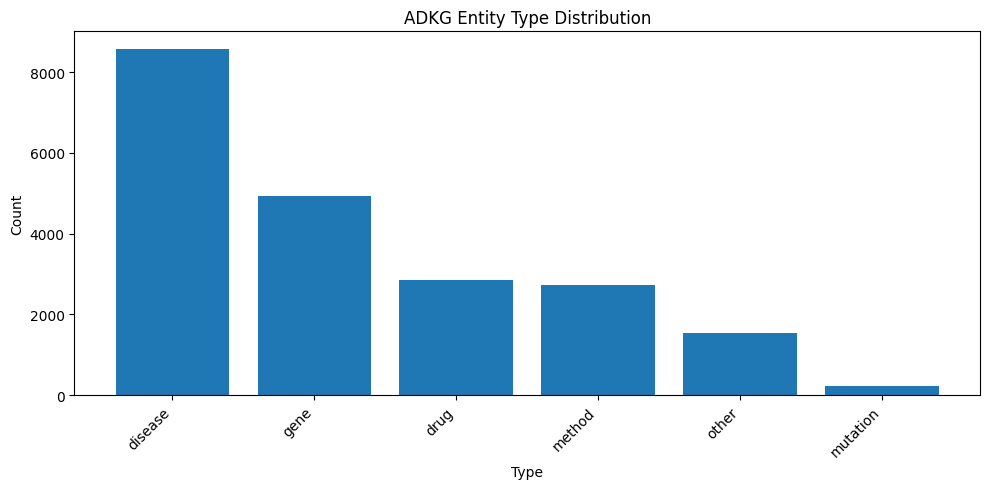

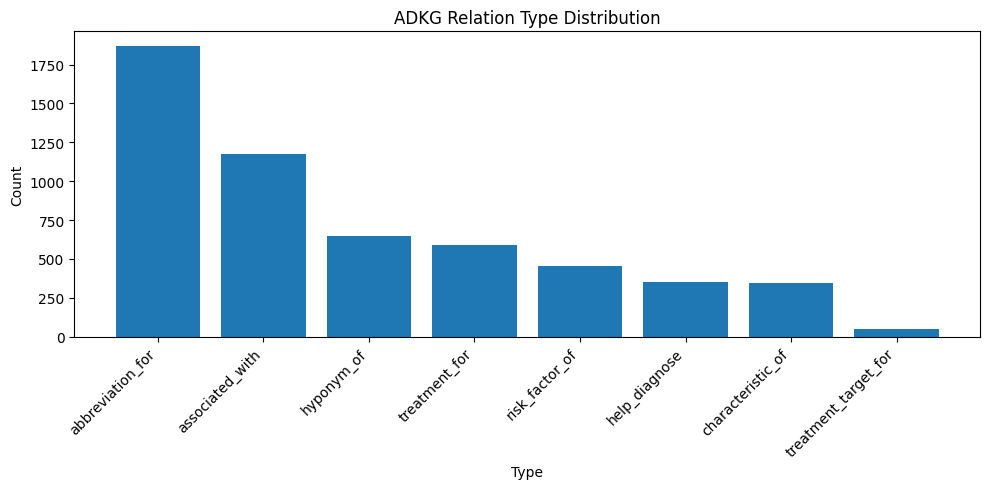

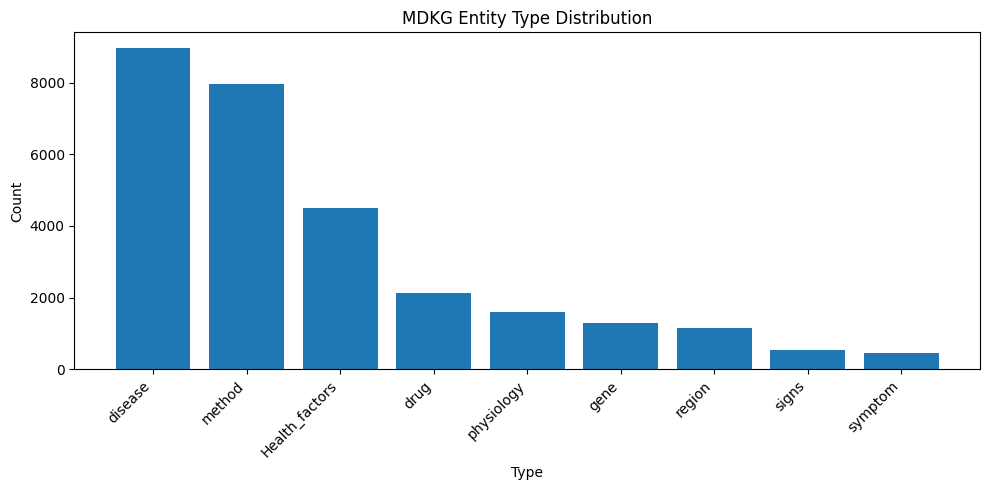

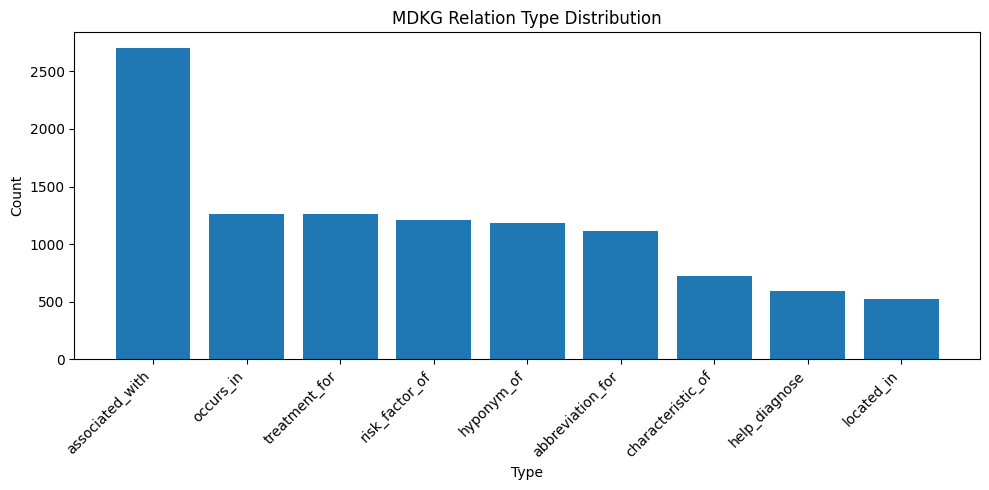

In [10]:
def plot_counter(counter, title):
    df = pd.DataFrame(counter.items(), columns=["type", "count"])
    df = df.sort_values("count", ascending=False)
    
    plt.figure(figsize=(10, 5))
    plt.bar(df["type"], df["count"])
    plt.xticks(rotation=45, ha="right")
    plt.title(title)
    plt.xlabel("Type")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

plot_counter(adkg_entity_counts, "ADKG Entity Type Distribution")
plot_counter(adkg_relation_counts, "ADKG Relation Type Distribution")
plot_counter(mdkg_entity_counts, "MDKG Entity Type Distribution")
plot_counter(mdkg_relation_counts, "MDKG Relation Type Distribution")

In [11]:
%%writefile scripts/create_spert_types.py

import json
import os


def make_type_file(label_path, out_path):
    with open(label_path, "r", encoding="utf-8") as f:
        labels = json.load(f)

    entity_types = {}

    for label in labels["entity_labels"]:
        entity_types[label] = {
            "short": label,
            "verbose": label
        }

    relation_types = {}

    for label in labels["relation_labels"]:
        relation_types[label] = {
            "short": label,
            "verbose": label,
            "symmetric": False
        }

    type_file = {
        "entities": entity_types,
        "relations": relation_types
    }

    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(type_file, f, indent=2)

    print(f"wrote {out_path}")


if __name__ == "__main__":
    os.makedirs("data/types", exist_ok=True)

    make_type_file(
        "data/datasets/adkg/labels.json",
        "data/types/adkg_types.json"
    )

    make_type_file(
        "data/datasets/mdkg/labels.json",
        "data/types/mdkg_types.json"
    )

Overwriting scripts/create_spert_types.py


In [12]:
!python scripts/create_spert_types.py

wrote data/types/adkg_types.json
wrote data/types/mdkg_types.json


In [13]:
!ls data/types

adkg_types.json  mdkg_types.json


In [14]:
!rm -rf data/save/adkg_train_test
!rm -rf data/log/adkg_train_test
!rm -rf outputs/adkg_entity_test

In [15]:
!nvidia-smi

Wed May  6 22:14:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 590.48.01              Driver Version: 590.48.01      CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-PCIE-40GB          On  |   00000000:21:00.0 Off |                    0 |
| N/A   30C    P0             33W /  250W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [16]:
import torch
print(torch.cuda.is_available())
print(torch.version.cuda)

True
12.1


In [17]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

CUDA available: True
CUDA version: 12.1
GPU count: 1


In [18]:
!ls configs

example_eval.conf     example_train.conf  train_adkg_test.conf
example_predict.conf  train_adkg.conf	  train_mdkg.conf


In [19]:
!cat configs/example_train.conf

[1]
label = conll04_train
model_type = spert
model_path = bert-base-cased
tokenizer_path = bert-base-cased
train_path = data/datasets/conll04/conll04_train.json
valid_path = data/datasets/conll04/conll04_dev.json
types_path = data/datasets/conll04/conll04_types.json
train_batch_size = 2
eval_batch_size = 1
neg_entity_count = 100
neg_relation_count = 100
epochs = 20
lr = 5e-5
lr_warmup = 0.1
weight_decay = 0.01
max_grad_norm = 1.0
rel_filter_threshold = 0.4
size_embedding = 25
prop_drop = 0.1
max_span_size = 10
store_predictions = true
store_examples = true
sampling_processes = 4
max_pairs = 1000
final_eval = true
log_path = data/log/
save_path = data/save/

In [20]:
%%writefile configs/train_adkg.conf
label = adkg_train
model_type = spert
model_path = allenai/scibert_scivocab_uncased
tokenizer_path = allenai/scibert_scivocab_uncased
train_path = data/datasets/adkg/train.json
valid_path = data/datasets/adkg/dev.json
types_path = data/types/adkg_types.json
train_batch_size = 2
eval_batch_size = 1
neg_entity_count = 100
neg_relation_count = 100
epochs = 3
lr = 5e-5
lr_warmup = 0.1
weight_decay = 0.01
max_grad_norm = 1.0
rel_filter_threshold = 0.4
size_embedding = 25
prop_drop = 0.1
max_span_size = 10
store_predictions = true
store_examples = true
sampling_processes = 0
max_pairs = 1000
final_eval = true
log_path = data/log/
save_path = data/save/

Overwriting configs/train_adkg.conf


In [21]:
!python spert.py train --config configs/train_adkg.conf

--------------------------------------------------
Config:
{'label': 'adkg_train', 'model_type': 'spert', 'model_path': 'allenai/scibert_scivocab_uncased', 'tokenizer_path': 'allenai/scibert_scivocab_uncased', 'train_path': 'data/datasets/adkg/train.json', 'valid_path': 'data/datasets/adkg/dev.json', 'types_path': 'data/types/adkg_types.json', 'train_batch_size': '2', 'eval_batch_size': '1', 'neg_entity_count': '100', 'neg_relation_count': '100', 'epochs': '3', 'lr': '5e-5', 'lr_warmup': '0.1', 'weight_decay': '0.01', 'max_grad_norm': '1.0', 'rel_filter_threshold': '0.4', 'size_embedding': '25', 'prop_drop': '0.1', 'max_span_size': '10', 'store_predictions': 'true', 'store_examples': 'true', 'sampling_processes': '0', 'max_pairs': '1000', 'final_eval': 'true', 'log_path': 'data/log/', 'save_path': 'data/save/'}
Repeat 1 times
--------------------------------------------------
Iteration 0
--------------------------------------------------
/nas/longleaf/home/amele/.local/lib/python3.11/s

In [22]:
%%writefile configs/train_mdkg.conf
label = mdkg_train
model_type = spert
model_path = allenai/scibert_scivocab_uncased
tokenizer_path = allenai/scibert_scivocab_uncased
train_path = data/datasets/mdkg/train.json
valid_path = data/datasets/mdkg/dev.json
types_path = data/types/mdkg_types.json
train_batch_size = 2
eval_batch_size = 1
neg_entity_count = 100
neg_relation_count = 100
epochs = 3
lr = 5e-5
lr_warmup = 0.1
weight_decay = 0.01
max_grad_norm = 1.0
rel_filter_threshold = 0.4
size_embedding = 25
prop_drop = 0.1
max_span_size = 10
store_predictions = true
store_examples = true
sampling_processes = 0
max_pairs = 1000
final_eval = true
log_path = data/log/
save_path = data/save/

Overwriting configs/train_mdkg.conf


In [23]:
!python spert.py train --config configs/train_mdkg.conf

--------------------------------------------------
Config:
{'label': 'mdkg_train', 'model_type': 'spert', 'model_path': 'allenai/scibert_scivocab_uncased', 'tokenizer_path': 'allenai/scibert_scivocab_uncased', 'train_path': 'data/datasets/mdkg/train.json', 'valid_path': 'data/datasets/mdkg/dev.json', 'types_path': 'data/types/mdkg_types.json', 'train_batch_size': '2', 'eval_batch_size': '1', 'neg_entity_count': '100', 'neg_relation_count': '100', 'epochs': '3', 'lr': '5e-5', 'lr_warmup': '0.1', 'weight_decay': '0.01', 'max_grad_norm': '1.0', 'rel_filter_threshold': '0.4', 'size_embedding': '25', 'prop_drop': '0.1', 'max_span_size': '10', 'store_predictions': 'true', 'store_examples': 'true', 'sampling_processes': '0', 'max_pairs': '1000', 'final_eval': 'true', 'log_path': 'data/log/', 'save_path': 'data/save/'}
Repeat 1 times
--------------------------------------------------
Iteration 0
--------------------------------------------------
/nas/longleaf/home/amele/.local/lib/python3.11/s

In [39]:
%%writefile configs/eval_adkg.conf
label = adkg_eval
model_type = spert
model_path = data/save/adkg_train/2026-05-06_22:15:01.289682/final_model
tokenizer_path = allenai/scibert_scivocab_uncased
dataset_path = data/datasets/adkg/test.json
types_path = data/types/adkg_types.json
eval_batch_size = 1
rel_filter_threshold = 0.4
size_embedding = 25
prop_drop = 0.1
max_span_size = 10
store_predictions = true
store_examples = true
max_pairs = 1000
log_path = data/log/

Overwriting configs/eval_adkg.conf


In [40]:
%%writefile configs/eval_mdkg.conf
label = mdkg_eval
model_type = spert
model_path = data/save/mdkg_train/2026-05-06_22:21:15.722606/final_model
tokenizer_path = allenai/scibert_scivocab_uncased
dataset_path = data/datasets/mdkg/test.json
types_path = data/types/mdkg_types.json
eval_batch_size = 1
rel_filter_threshold = 0.4
size_embedding = 25
prop_drop = 0.1
max_span_size = 10
store_predictions = true
store_examples = true
max_pairs = 1000
log_path = data/log/

Overwriting configs/eval_mdkg.conf


In [41]:
!python spert.py eval --config configs/eval_adkg.conf

--------------------------------------------------
Config:
{'label': 'adkg_eval', 'model_type': 'spert', 'model_path': 'data/save/adkg_train/2026-05-06_22:15:01.289682/final_model', 'tokenizer_path': 'allenai/scibert_scivocab_uncased', 'dataset_path': 'data/datasets/adkg/test.json', 'types_path': 'data/types/adkg_types.json', 'eval_batch_size': '1', 'rel_filter_threshold': '0.4', 'size_embedding': '25', 'prop_drop': '0.1', 'max_span_size': '10', 'store_predictions': 'true', 'store_examples': 'true', 'max_pairs': '1000', 'log_path': 'data/log/'}
Repeat 1 times
--------------------------------------------------
Iteration 0
--------------------------------------------------
/nas/longleaf/home/amele/.local/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
2026-05-06 22:37

In [42]:
!python spert.py eval --config configs/eval_mdkg.conf

--------------------------------------------------
Config:
{'label': 'mdkg_eval', 'model_type': 'spert', 'model_path': 'data/save/mdkg_train/2026-05-06_22:21:15.722606/final_model', 'tokenizer_path': 'allenai/scibert_scivocab_uncased', 'dataset_path': 'data/datasets/mdkg/test.json', 'types_path': 'data/types/mdkg_types.json', 'eval_batch_size': '1', 'rel_filter_threshold': '0.4', 'size_embedding': '25', 'prop_drop': '0.1', 'max_span_size': '10', 'store_predictions': 'true', 'store_examples': 'true', 'max_pairs': '1000', 'log_path': 'data/log/'}
Repeat 1 times
--------------------------------------------------
Iteration 0
--------------------------------------------------
/nas/longleaf/home/amele/.local/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
2026-05-06 22:38

In [43]:
!find data -type f | grep -E "pred|example|json" | head -100

data/datasets/adkg/train.json
data/datasets/adkg/dev.json
data/datasets/adkg/test.json
data/datasets/adkg/labels.json
data/datasets/mdkg/train.json
data/datasets/mdkg/dev.json
data/datasets/mdkg/test.json
data/datasets/mdkg/labels.json
data/types/adkg_types.json
data/types/mdkg_types.json
data/save/adkg_train/2026-05-06_21:39:44.299680/final_model/config.json
data/save/adkg_train/2026-05-06_21:39:44.299680/final_model/tokenizer_config.json
data/save/adkg_train/2026-05-06_21:39:44.299680/final_model/special_tokens_map.json
data/save/adkg_train/2026-05-06_21:47:44.006873/final_model/config.json
data/save/adkg_train/2026-05-06_21:47:44.006873/final_model/tokenizer_config.json
data/save/adkg_train/2026-05-06_21:47:44.006873/final_model/special_tokens_map.json
data/save/adkg_train/2026-05-06_22:15:01.289682/final_model/config.json
data/save/adkg_train/2026-05-06_22:15:01.289682/final_model/tokenizer_config.json
data/save/adkg_train/2026-05-06_22:15:01.289682/final_model/special_tokens_map.j

<class 'list'>
1220
{'tokens': ['Alpha', '-', 'amylase', '1A', 'copy', 'number', 'variants', 'and', 'the', 'association', 'with', 'memory', 'performance', 'and', 'Alzheimer', "'", 's', 'dementia', '.'], 'entities': [{'type': 'other', 'start': 11, 'end': 13}, {'type': 'disease', 'start': 14, 'end': 18}], 'relations': []}


In [45]:


def sentence_difficulty_table(path, dataset_name):
    with open(path, "r") as f:
        data = json.load(f)

    rows = []

    for split in ["train", "dev", "test"]:
        for ex in data[split]:
            rows.append({
                "dataset": dataset_name,
                "split": split,
                "sent_id": ex["sent_id"],
                "text": ex["text"],
                "num_chars": len(ex["text"]),
                "num_entities": len(ex["entities"]),
                "num_relations": len(ex["relations"])
            })

    return pd.DataFrame(rows)

adkg_diff = sentence_difficulty_table("ADKG.json", "ADKG")
mdkg_diff = sentence_difficulty_table("MDKG.json", "MDKG")

difficulty_df = pd.concat([adkg_diff, mdkg_diff])
difficulty_df.sort_values(["num_entities", "num_relations", "num_chars"], ascending=False).head(10)

,dataset,split,sent_id,text,num_chars,num_entities,num_relations
2371,MDKG,train,20221122_8_s0,METHODS: We used bi-directional two-sample Men...,775,44,30
3727,MDKG,train,34002501_s7,"Based on the meta-analytic evidence, the most ...",932,39,25
2515,MDKG,train,20221103_19_s0,These findings include the following: (a) redu...,1146,39,23
4785,MDKG,train,20221122_15_s0,Exercise training demonstrated significant red...,846,34,6
1510,MDKG,train,38214616_s3,"We included 415 studies (N=88,372, mean age: 2...",740,30,22
5406,MDKG,dev,27706475_s12,An increased risk for OCD remained after contr...,690,29,1
7165,ADKG,test,26738859_s2,"Here, in order to discover potential AD-relate...",545,28,13
1313,MDKG,train,37218308_s7,Subgroup analysis showed that the benefits of ...,514,28,5
2754,MDKG,train,20221122_14_s0,In multivariable analyses adjusting for matern...,555,26,5
2650,MDKG,train,35524619_s7,Specific-cause mortality was highest for suici...,515,26,2


In [46]:
def find_overlapping_entities(data, dataset_name):
    rows = []

    for split in ["train", "dev", "test"]:
        for ex in data[split]:
            ents = ex["entities"]

            for i in range(len(ents)):
                for j in range(i + 1, len(ents)):
                    e1 = ents[i]
                    e2 = ents[j]

                    overlap = max(e1["start"], e2["start"]) < min(e1["end"], e2["end"])

                    if overlap:
                        rows.append({
                            "dataset": dataset_name,
                            "split": split,
                            "sent_id": ex["sent_id"],
                            "text": ex["text"],
                            "entity_1": e1["text"],
                            "type_1": e1["type"],
                            "entity_2": e2["text"],
                            "type_2": e2["type"]
                        })

    return pd.DataFrame(rows)

with open("ADKG.json", "r") as f:
    adkg = json.load(f)

with open("MDKG.json", "r") as f:
    mdkg = json.load(f)

overlap_df = pd.concat([
    find_overlapping_entities(adkg, "ADKG"),
    find_overlapping_entities(mdkg, "MDKG")
])

overlap_df.head(20)

,dataset,split,sent_id,text,entity_1,type_1,entity_2,type_2
0,ADKG,train,32854315_s1,Pathological hallmarks of Alzheimer's disease ...,deposits of amyloid beta,other,amyloid beta,gene
1,ADKG,train,32916120_s3,Using ultra-high-field (7T) functional magneti...,ultra-high-field (7T) functional magnetic reso...,method,functional magnetic resonance imaging,method
2,ADKG,train,30466464_s1,BACKGROUND: Although diabetic retinopathy (DR)...,dysfunction of retinal ganglion cells,disease,retinal ganglion cells,other
3,ADKG,train,31383337_s2,"This prospect, if methodically probed, could f...",per-residue energy decomposition,other,per-residue energy decomposition (PRED) protocol,method
4,ADKG,train,31383337_s2,"This prospect, if methodically probed, could f...",per-residue energy decomposition (PRED) protocol,method,PRED,other
5,ADKG,train,26253607_s7,"However, Abeta42 levels in ET individuals were...",unphosphorylated neurofilament heavy chain,gene,neurofilament heavy chain,gene
6,ADKG,train,29760756_s3,Methods: The current study evaluated alpha-syn...,acute myeloblastic leukemia,disease,acute myeloblastic leukemia (AML)-M6,disease
7,ADKG,train,29760756_s3,Methods: The current study evaluated alpha-syn...,acute myeloblastic leukemia (AML)-M6,disease,AML,disease
8,ADKG,train,30031930_s6,Tumour necrosis factor (TNF)-alpha and CCL3 le...,Tumour necrosis factor,gene,Tumour necrosis factor (TNF)-alpha,gene
9,ADKG,train,30031930_s6,Tumour necrosis factor (TNF)-alpha and CCL3 le...,Tumour necrosis factor (TNF)-alpha,gene,TNF,gene


In [47]:
def relation_distance_table(data, dataset_name):
    rows = []

    for split in ["train", "dev", "test"]:
        for ex in data[split]:
            for rel in ex["relations"]:
                h = rel["head"]
                t = rel["tail"]

                rows.append({
                    "dataset": dataset_name,
                    "split": split,
                    "sent_id": ex["sent_id"],
                    "text": ex["text"],
                    "relation": rel["type"],
                    "head": h["text"],
                    "tail": t["text"],
                    "char_distance": abs(h["start"] - t["start"])
                })

    return pd.DataFrame(rows)

rel_dist_df = pd.concat([
    relation_distance_table(adkg, "ADKG"),
    relation_distance_table(mdkg, "MDKG")
])

rel_dist_df.sort_values("char_distance", ascending=False).head(10)

,dataset,split,sent_id,text,relation,head,tail,char_distance
7997,MDKG,dev,26873185_s7,Patients with bipolar disorder and history of ...,risk_factor_of,bipolar disorder,suicide attempt,1084
7998,MDKG,dev,26873185_s7,Patients with bipolar disorder and history of ...,risk_factor_of,history of childhood maltreatment,suicide attempt,1063
7995,MDKG,dev,26873185_s7,Patients with bipolar disorder and history of ...,risk_factor_of,bipolar disorder,depressive episodes,987
7996,MDKG,dev,26873185_s7,Patients with bipolar disorder and history of ...,risk_factor_of,history of childhood maltreatment,depressive episodes,966
7993,MDKG,dev,26873185_s7,Patients with bipolar disorder and history of ...,risk_factor_of,bipolar disorder,manic episodes,896
7994,MDKG,dev,26873185_s7,Patients with bipolar disorder and history of ...,risk_factor_of,history of childhood maltreatment,manic episodes,875
7991,MDKG,dev,26873185_s7,Patients with bipolar disorder and history of ...,risk_factor_of,bipolar disorder,rapid cycling,805
7992,MDKG,dev,26873185_s7,Patients with bipolar disorder and history of ...,risk_factor_of,history of childhood maltreatment,rapid cycling,784
7989,MDKG,dev,26873185_s7,Patients with bipolar disorder and history of ...,risk_factor_of,bipolar disorder,age of bipolar disorder onset,704
7990,MDKG,dev,26873185_s7,Patients with bipolar disorder and history of ...,risk_factor_of,history of childhood maltreatment,age of bipolar disorder onset,683


In [48]:
%%writefile scripts/compute_spert_metrics.py

import json
import argparse
from collections import defaultdict
import pandas as pd


def safe_div(a, b):
    return a / b if b else 0.0


def prf(correct, pred, gold):
    p = safe_div(correct, pred)
    r = safe_div(correct, gold)
    f1 = safe_div(2 * p * r, p + r)
    return p, r, f1


def entity_set(example):
    return set(
        (ent["start"], ent["end"], ent["type"])
        for ent in example["entities"]
    )


def relation_set(example):
    """
    Convert relations to span-based format:
    head_start, head_end, head_type, tail_start, tail_end, tail_type, relation_type
    """
    entities = example["entities"]
    rels = set()

    for rel in example["relations"]:
        head = entities[rel["head"]]
        tail = entities[rel["tail"]]

        rels.add((
            head["start"],
            head["end"],
            head["type"],
            tail["start"],
            tail["end"],
            tail["type"],
            rel["type"]
        ))

    return rels


def compute_entity_metrics(gold_data, pred_data):
    by_type = defaultdict(lambda: {"gold": 0, "pred": 0, "correct": 0})

    total_gold = 0
    total_pred = 0
    total_correct = 0

    for gold_ex, pred_ex in zip(gold_data, pred_data):
        gold = entity_set(gold_ex)
        pred = entity_set(pred_ex)

        total_gold += len(gold)
        total_pred += len(pred)
        total_correct += len(gold & pred)

        for item in gold:
            by_type[item[2]]["gold"] += 1

        for item in pred:
            by_type[item[2]]["pred"] += 1

        for item in gold & pred:
            by_type[item[2]]["correct"] += 1

    rows = []

    for label, counts in sorted(by_type.items()):
        p, r, f1 = prf(counts["correct"], counts["pred"], counts["gold"])
        rows.append({
            "kind": "entity",
            "type": label,
            "precision": p,
            "recall": r,
            "f1": f1,
            "gold": counts["gold"],
            "pred": counts["pred"],
            "correct": counts["correct"]
        })

    p, r, f1 = prf(total_correct, total_pred, total_gold)
    rows.append({
        "kind": "entity",
        "type": "OVERALL",
        "precision": p,
        "recall": r,
        "f1": f1,
        "gold": total_gold,
        "pred": total_pred,
        "correct": total_correct
    })

    return rows


def compute_relation_metrics(gold_data, pred_data):
    by_type = defaultdict(lambda: {"gold": 0, "pred": 0, "correct": 0})

    total_gold = 0
    total_pred = 0
    total_correct = 0

    for gold_ex, pred_ex in zip(gold_data, pred_data):
        gold = relation_set(gold_ex)
        pred = relation_set(pred_ex)

        total_gold += len(gold)
        total_pred += len(pred)
        total_correct += len(gold & pred)

        for item in gold:
            by_type[item[-1]]["gold"] += 1

        for item in pred:
            by_type[item[-1]]["pred"] += 1

        for item in gold & pred:
            by_type[item[-1]]["correct"] += 1

    rows = []

    for label, counts in sorted(by_type.items()):
        p, r, f1 = prf(counts["correct"], counts["pred"], counts["gold"])
        rows.append({
            "kind": "relation",
            "type": label,
            "precision": p,
            "recall": r,
            "f1": f1,
            "gold": counts["gold"],
            "pred": counts["pred"],
            "correct": counts["correct"]
        })

    p, r, f1 = prf(total_correct, total_pred, total_gold)
    rows.append({
        "kind": "relation",
        "type": "OVERALL",
        "precision": p,
        "recall": r,
        "f1": f1,
        "gold": total_gold,
        "pred": total_pred,
        "correct": total_correct
    })

    return rows


if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--gold", required=True)
    parser.add_argument("--pred", required=True)
    parser.add_argument("--out", required=True)
    args = parser.parse_args()

    with open(args.gold, "r") as f:
        gold_data = json.load(f)

    with open(args.pred, "r") as f:
        pred_data = json.load(f)

    assert len(gold_data) == len(pred_data), "Gold and prediction files have different lengths."

    rows = []
    rows += compute_entity_metrics(gold_data, pred_data)
    rows += compute_relation_metrics(gold_data, pred_data)

    df = pd.DataFrame(rows)
    df.to_csv(args.out, index=False)

    print(df)
    print(f"Saved metrics to {args.out}")

Writing scripts/compute_spert_metrics.py


In [49]:
!python scripts/compute_spert_metrics.py \
  --gold data/datasets/adkg/test.json \
  --pred data/log/adkg_eval/2026-05-06_22:37:58.509020/predictions_test_epoch_0.json \
  --out outputs/adkg_spert_metrics.csv

        kind                  type  precision  ...  gold  pred  correct
0     entity               disease   0.796282  ...  1199  1291     1028
1     entity                  drug   0.684760  ...   485   479      328
2     entity                  gene   0.652838  ...   812   916      598
3     entity                method   0.447983  ...   406   471      211
4     entity              mutation   0.603175  ...    46    63       38
5     entity                 other   0.313084  ...   201   214       67
6     entity               OVERALL   0.661037  ...  3149  3434     2270
7   relation      abbreviation_for   0.613095  ...   268   336      206
8   relation       associated_with   0.129630  ...   161   162       21
9   relation     characteristic_of   0.363636  ...    48    22        8
10  relation         help_diagnose   0.236842  ...    52    38        9
11  relation            hyponym_of   0.299270  ...    93   137       41
12  relation        risk_factor_of   0.212121  ...    59    66  

In [50]:
!python scripts/compute_spert_metrics.py \
  --gold data/datasets/mdkg/test.json \
  --pred data/log/mdkg_eval/2026-05-06_22:38:51.684881/predictions_test_epoch_0.json \
  --out outputs/mdkg_spert_metrics.csv

        kind               type  precision  ...  gold  pred  correct
0     entity     Health_factors   0.725601  ...   675   707      513
1     entity            disease   0.869231  ...  1228  1300     1130
2     entity               drug   0.697368  ...   248   304      212
3     entity               gene   0.696970  ...   214   231      161
4     entity             method   0.755319  ...  1104  1222      923
5     entity         physiology   0.637736  ...   243   265      169
6     entity             region   0.705128  ...   137   156      110
7     entity              signs   0.573529  ...    60    68       39
8     entity            symptom   0.500000  ...    51    38       19
9     entity            OVERALL   0.763458  ...  3960  4291     3276
10  relation   abbreviation_for   0.732919  ...   149   161      118
11  relation    associated_with   0.354839  ...   425   403      143
12  relation  characteristic_of   0.260274  ...   106    73       19
13  relation      help_diagnose   

In [53]:


adkg_metrics = pd.read_csv("outputs/adkg_spert_metrics.csv")
mdkg_metrics = pd.read_csv("outputs/mdkg_spert_metrics.csv")

adkg_metrics

,kind,type,precision,recall,f1,gold,pred,correct
0,entity,disease,0.796282,0.857381,0.825703,1199,1291,1028
1,entity,drug,0.684760,0.676289,0.680498,485,479,328
2,entity,gene,0.652838,0.736453,0.692130,812,916,598
3,entity,method,0.447983,0.519704,0.481186,406,471,211
4,entity,mutation,0.603175,0.826087,0.697248,46,63,38
5,entity,other,0.313084,0.333333,0.322892,201,214,67
6,entity,OVERALL,0.661037,0.720864,0.689655,3149,3434,2270
7,relation,abbreviation_for,0.613095,0.768657,0.682119,268,336,206
8,relation,associated_with,0.129630,0.130435,0.130031,161,162,21
9,relation,characteristic_of,0.363636,0.166667,0.228571,48,22,8


In [54]:
def get_overall(df, dataset):
    ent = df[(df["kind"] == "entity") & (df["type"] == "OVERALL")].iloc[0]
    rel = df[(df["kind"] == "relation") & (df["type"] == "OVERALL")].iloc[0]

    return {
        "Dataset": dataset,
        "Entity P": round(ent["precision"], 4),
        "Entity R": round(ent["recall"], 4),
        "Entity F1": round(ent["f1"], 4),
        "Relation P": round(rel["precision"], 4),
        "Relation R": round(rel["recall"], 4),
        "Relation F1": round(rel["f1"], 4)
    }

main_results = pd.DataFrame([
    get_overall(adkg_metrics, "ADKG"),
    get_overall(mdkg_metrics, "MDKG")
])

main_results

,Dataset,Entity P,Entity R,Entity F1,Relation P,Relation R,Relation F1
0,ADKG,0.6610,0.7209,0.6897,0.3729,0.4252,0.3973
1,MDKG,0.7635,0.8273,0.7941,0.4554,0.4783,0.4666


In [55]:
adkg_metrics[adkg_metrics["kind"] == "relation"].sort_values("f1", ascending=False)

,kind,type,precision,recall,f1,gold,pred,correct
7,relation,abbreviation_for,0.613095,0.768657,0.682119,268,336,206
15,relation,OVERALL,0.372862,0.425228,0.397327,769,877,327
11,relation,hyponym_of,0.299270,0.440860,0.356522,93,137,41
13,relation,treatment_for,0.247788,0.354430,0.291667,79,113,28
9,relation,characteristic_of,0.363636,0.166667,0.228571,48,22,8
12,relation,risk_factor_of,0.212121,0.237288,0.224000,59,66,14
10,relation,help_diagnose,0.236842,0.173077,0.200000,52,38,9
8,relation,associated_with,0.129630,0.130435,0.130031,161,162,21
14,relation,treatment_target_for,0.000000,0.000000,0.000000,9,3,0


In [56]:
mdkg_metrics[mdkg_metrics["kind"] == "relation"].sort_values("f1", ascending=False)

,kind,type,precision,recall,f1,gold,pred,correct
10,relation,abbreviation_for,0.732919,0.791946,0.761290,149,161,118
14,relation,hyponym_of,0.530000,0.679487,0.595506,156,200,106
16,relation,occurs_in,0.502646,0.669014,0.574018,142,189,95
17,relation,risk_factor_of,0.547445,0.471698,0.506757,159,137,75
13,relation,help_diagnose,0.403846,0.591549,0.480000,71,104,42
19,relation,OVERALL,0.455393,0.478322,0.466576,1430,1502,684
18,relation,treatment_for,0.376543,0.417808,0.396104,146,162,61
11,relation,associated_with,0.354839,0.336471,0.345411,425,403,143
15,relation,located_in,0.342466,0.328947,0.335570,76,73,25
12,relation,characteristic_of,0.260274,0.179245,0.212291,106,73,19


In [57]:
adkg_metrics[adkg_metrics["kind"] == "entity"].sort_values("f1", ascending=False)

,kind,type,precision,recall,f1,gold,pred,correct
0,entity,disease,0.796282,0.857381,0.825703,1199,1291,1028
4,entity,mutation,0.603175,0.826087,0.697248,46,63,38
2,entity,gene,0.652838,0.736453,0.692130,812,916,598
6,entity,OVERALL,0.661037,0.720864,0.689655,3149,3434,2270
1,entity,drug,0.684760,0.676289,0.680498,485,479,328
3,entity,method,0.447983,0.519704,0.481186,406,471,211
5,entity,other,0.313084,0.333333,0.322892,201,214,67


In [62]:
mdkg_metrics[mdkg_metrics["kind"] == "entity"].sort_values("f1", ascending=False)

,kind,type,precision,recall,f1,gold,pred,correct
1,entity,disease,0.869231,0.920195,0.893987,1228,1300,1130
9,entity,OVERALL,0.763458,0.827273,0.794086,3960,4291,3276
4,entity,method,0.755319,0.836051,0.793637,1104,1222,923
2,entity,drug,0.697368,0.854839,0.768116,248,304,212
6,entity,region,0.705128,0.802920,0.750853,137,156,110
0,entity,Health_factors,0.725601,0.760000,0.742402,675,707,513
3,entity,gene,0.696970,0.752336,0.723596,214,231,161
5,entity,physiology,0.637736,0.695473,0.665354,243,265,169
7,entity,signs,0.573529,0.650000,0.609375,60,68,39
8,entity,symptom,0.500000,0.372549,0.426966,51,38,19


In [59]:
difficulty_df.sort_values(["num_entities", "num_relations", "num_chars"], ascending=False).head(5)


,dataset,split,sent_id,text,num_chars,num_entities,num_relations
2371,MDKG,train,20221122_8_s0,METHODS: We used bi-directional two-sample Men...,775,44,30
3727,MDKG,train,34002501_s7,"Based on the meta-analytic evidence, the most ...",932,39,25
2515,MDKG,train,20221103_19_s0,These findings include the following: (a) redu...,1146,39,23
4785,MDKG,train,20221122_15_s0,Exercise training demonstrated significant red...,846,34,6
1510,MDKG,train,38214616_s3,"We included 415 studies (N=88,372, mean age: 2...",740,30,22


In [60]:
overlap_df.head(10)

,dataset,split,sent_id,text,entity_1,type_1,entity_2,type_2
0,ADKG,train,32854315_s1,Pathological hallmarks of Alzheimer's disease ...,deposits of amyloid beta,other,amyloid beta,gene
1,ADKG,train,32916120_s3,Using ultra-high-field (7T) functional magneti...,ultra-high-field (7T) functional magnetic reso...,method,functional magnetic resonance imaging,method
2,ADKG,train,30466464_s1,BACKGROUND: Although diabetic retinopathy (DR)...,dysfunction of retinal ganglion cells,disease,retinal ganglion cells,other
3,ADKG,train,31383337_s2,"This prospect, if methodically probed, could f...",per-residue energy decomposition,other,per-residue energy decomposition (PRED) protocol,method
4,ADKG,train,31383337_s2,"This prospect, if methodically probed, could f...",per-residue energy decomposition (PRED) protocol,method,PRED,other
5,ADKG,train,26253607_s7,"However, Abeta42 levels in ET individuals were...",unphosphorylated neurofilament heavy chain,gene,neurofilament heavy chain,gene
6,ADKG,train,29760756_s3,Methods: The current study evaluated alpha-syn...,acute myeloblastic leukemia,disease,acute myeloblastic leukemia (AML)-M6,disease
7,ADKG,train,29760756_s3,Methods: The current study evaluated alpha-syn...,acute myeloblastic leukemia (AML)-M6,disease,AML,disease
8,ADKG,train,30031930_s6,Tumour necrosis factor (TNF)-alpha and CCL3 le...,Tumour necrosis factor,gene,Tumour necrosis factor (TNF)-alpha,gene
9,ADKG,train,30031930_s6,Tumour necrosis factor (TNF)-alpha and CCL3 le...,Tumour necrosis factor (TNF)-alpha,gene,TNF,gene


In [61]:
rel_dist_df.sort_values("char_distance", ascending=False).head(10)

,dataset,split,sent_id,text,relation,head,tail,char_distance
7997,MDKG,dev,26873185_s7,Patients with bipolar disorder and history of ...,risk_factor_of,bipolar disorder,suicide attempt,1084
7998,MDKG,dev,26873185_s7,Patients with bipolar disorder and history of ...,risk_factor_of,history of childhood maltreatment,suicide attempt,1063
7995,MDKG,dev,26873185_s7,Patients with bipolar disorder and history of ...,risk_factor_of,bipolar disorder,depressive episodes,987
7996,MDKG,dev,26873185_s7,Patients with bipolar disorder and history of ...,risk_factor_of,history of childhood maltreatment,depressive episodes,966
7993,MDKG,dev,26873185_s7,Patients with bipolar disorder and history of ...,risk_factor_of,bipolar disorder,manic episodes,896
7994,MDKG,dev,26873185_s7,Patients with bipolar disorder and history of ...,risk_factor_of,history of childhood maltreatment,manic episodes,875
7991,MDKG,dev,26873185_s7,Patients with bipolar disorder and history of ...,risk_factor_of,bipolar disorder,rapid cycling,805
7992,MDKG,dev,26873185_s7,Patients with bipolar disorder and history of ...,risk_factor_of,history of childhood maltreatment,rapid cycling,784
7989,MDKG,dev,26873185_s7,Patients with bipolar disorder and history of ...,risk_factor_of,bipolar disorder,age of bipolar disorder onset,704
7990,MDKG,dev,26873185_s7,Patients with bipolar disorder and history of ...,risk_factor_of,history of childhood maltreatment,age of bipolar disorder onset,683
